# Half-Life Estimation for Mean Reversion Speed

The Brent–WTI spread does not appear to be consistently mean-reverting across the full sample. However, the stationarity analysis suggests that short-lived mean-reverting regimes do occur, with a 30-minute rolling window producing the strongest ADF/KPSS pass rates.

The goal of this analysis is therefore not to establish that the spread is globally mean-reverting (which we have already established is not the case), but to determine **how quickly it tends to revert when a locally stationary regime is identified**.

For each rolling window that passes both the ADF and KPSS stationarity tests, we estimate the spread's mean-reversion half-life using an AR(1) model:

$$
S_t = \alpha + \phi S_{t-1} + \epsilon_t
$$

with half-life:

$$
HL = -\frac{\ln(2)}{\ln(\phi)}
$$

We will examine the distribution and stability of these conditional half-life estimates to determine whether mean reversion is fast enough to support short-term intraday trades. The resulting estimates will be used to **define a maximum acceptable half-life for trade entry**, with the idea being that, for an intraday strategy we want short-term holding periods, and if the half-life for a window is too slow to support such a trade, we do not enter it. 

For the purposes of this analysis, we will run the AR(1) model on all 30-minute time windows within the data from June 1 to June 5 between 00:00 and 20:00 UTC that pass the ADF and KPSS stationarity tests, and analyze the distributions of the half-life estimates with the goal of determining what half-life limits would be appropriate for an intraday strategy. We will let our 30-minute time windows be overlapping (i.e. windows will include 00:00-00:30, 00:01-00:31, etc.), so that this analysis closely mimics what the strategy would look like running live on every minute. 

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


DATA_DIR = Path('/Users/bhuvaneshkodem/Documents/FinMath/FINM 37000 - Futures and Related Derivatives/finm37000-grp-6-trading/_data')

ALIGNED_DATA = (
    DATA_DIR
    / "clean"
    / "brent_wti_aligned_1m_2026-06-01_2026-06-06.parquet"
)

# Load aligned data file
aligned_1min = pd.read_parquet(ALIGNED_DATA)

# Ensure observations are ordered chronologically.
aligned_1min = aligned_1min.sort_index()

aligned_1min.head()

,cl_bid_px_00,cl_ask_px_00,cl_bid_sz_00,cl_ask_sz_00,cl_mid,cl_instrument_id,cl_n_events,cl_n_trades,cl_volume,cl_is_roll_date,...,ls_mid,ls_instrument_id,ls_n_events,ls_n_trades,ls_volume,ls_is_roll_date,synth_mid,synth_bid,synth_ask,is_roll_date
ts_recv,,,,,,,,,,,,,,,,,,,,,
2026-06-01 00:00:00+00:00,89.51,89.54,3.0,4.0,89.525,777566.0,416,40,46,False,...,-3.480,42016777.0,79,0,0,False,-3.485,-3.52,-3.45,False
2026-06-01 00:01:00+00:00,89.59,89.60,2.0,11.0,89.595,777566.0,271,18,25,False,...,-3.490,42016777.0,36,0,0,False,-3.480,-3.51,-3.45,False
2026-06-01 00:02:00+00:00,89.52,89.55,3.0,2.0,89.535,777566.0,248,18,19,False,...,-3.495,42016777.0,26,0,0,False,-3.500,-3.54,-3.46,False
2026-06-01 00:03:00+00:00,89.57,89.59,2.0,1.0,89.580,777566.0,186,18,33,False,...,-3.495,42016777.0,20,1,1,False,-3.495,-3.53,-3.46,False
2026-06-01 00:04:00+00:00,89.51,89.53,3.0,1.0,89.520,777566.0,594,43,60,False,...,-3.500,42016777.0,36,0,0,False,-3.510,-3.54,-3.48,False


In [37]:
# Construct the synthetic Brent-WTI spread
aligned_1min = aligned_1min[
    aligned_1min.index.hour < 20
]

spread = (
    aligned_1min["bz_mid"]
    - aligned_1min["cl_mid"]
).dropna()

spread.name = "synthetic_spread"
spread = spread

spread.head()

ts_recv
2026-06-01 00:00:00+00:00    3.485
2026-06-01 00:01:00+00:00    3.480
2026-06-01 00:02:00+00:00    3.500
2026-06-01 00:03:00+00:00    3.495
2026-06-01 00:04:00+00:00    3.510
Name: synthetic_spread, dtype: float64

In [38]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
import warnings

def test_stationarity(window, alpha=0.05):
    """
    Run ADF and KPSS tests on a spread window.

    A window is considered stationary if:
    - ADF rejects the unit-root null
    - KPSS fails to reject the stationarity null
    """

    adf_stat, adf_pvalue, *_ = adfuller(window)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)

    kpss_stat, kpss_pvalue, *_ = kpss(
        window,
        regression="c",
        nlags="auto",
    )

    adf_pass = adf_pvalue < alpha
    kpss_pass = kpss_pvalue > alpha

    return {
        "adf_pvalue": float(adf_pvalue),
        "kpss_pvalue": float(kpss_pvalue),
        "adf_pass": bool(adf_pass),
        "kpss_pass": bool(kpss_pass),
        "stationary": bool(adf_pass and kpss_pass),
    }

In [39]:
sample_window = spread.iloc[:30]

test_stationarity(sample_window)

/var/folders/jg/hg4078dn71d7q2w1mzkvkjm00000gn/T/ipykernel_37414/3714639244.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(


{'adf_pvalue': 0.015192591747299892,
 'kpss_pvalue': 0.1,
 'adf_pass': True,
 'kpss_pass': True,
 'stationary': True}

In [40]:
import numpy as np
import statsmodels.api as sm


def estimate_half_life(window):
    """
    Estimate AR(1) persistence and mean-reversion half-life
    for a spread window.

    Model:
        S_t = alpha + phi * S_{t-1} + epsilon_t

    Returns
    -------
    dict
        phi: estimated AR(1) coefficient
        half_life: implied half-life in observation periods
    """

    y = window.iloc[1:]
    x = window.shift(1).iloc[1:]

    x = sm.add_constant(x)

    model = sm.OLS(y, x).fit()

    phi = float(model.params.iloc[1])

    if 0 < phi < 1:
        half_life = float(-np.log(2) / np.log(phi))
    else:
        half_life = np.nan

    return {
        "phi": phi,
        "half_life": half_life,
    }

In [41]:
estimate_half_life(sample_window)

{'phi': 0.6785278878389667, 'half_life': 1.7872462668426325}

In [62]:
WINDOW = 30

results = []

for _, daily_spread in spread.groupby(spread.index.date):

    if len(daily_spread) < WINDOW:
        continue

    for end_idx in range(WINDOW, len(daily_spread) + 1):
        window = daily_spread.iloc[end_idx - WINDOW:end_idx]
        timestamp = window.index[-1]

        stationarity = test_stationarity(window)

        phi = np.nan
        half_life = np.nan

        if stationarity["stationary"]:
            hl_result = estimate_half_life(window)
            phi = hl_result["phi"]
            half_life = hl_result["half_life"]

        results.append({
            "timestamp": timestamp,
            "adf_pvalue": stationarity["adf_pvalue"],
            "kpss_pvalue": stationarity["kpss_pvalue"],
            "adf_pass": stationarity["adf_pass"],
            "kpss_pass": stationarity["kpss_pass"],
            "stationary": stationarity["stationary"],
            "phi": phi,
            "half_life": half_life,
        })

rolling_results = (
    pd.DataFrame(results)
    .set_index("timestamp")
)

rolling_results

/var/folders/jg/hg4078dn71d7q2w1mzkvkjm00000gn/T/ipykernel_37414/3714639244.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(
/var/folders/jg/hg4078dn71d7q2w1mzkvkjm00000gn/T/ipykernel_37414/3714639244.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(
/var/folders/jg/hg4078dn71d7q2w1mzkvkjm00000gn/T/ipykernel_37414/3714639244.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(
/var/folders/jg/hg4078dn71d7q2w1mzkvkjm00000gn/T/ipykernel_37414/3714639244.py:19: InterpolationWarning: The test statistic is outside of t

,adf_pvalue,kpss_pvalue,adf_pass,kpss_pass,stationary,phi,half_life
timestamp,,,,,,,
2026-06-01 00:29:00+00:00,0.015193,0.100000,True,True,True,0.678528,1.787246
2026-06-01 00:30:00+00:00,0.015094,0.100000,True,True,True,0.655359,1.640308
2026-06-01 00:31:00+00:00,0.327383,0.100000,False,True,False,NaN,NaN
2026-06-01 00:32:00+00:00,0.184570,0.100000,False,True,False,NaN,NaN
2026-06-01 00:33:00+00:00,0.170034,0.100000,False,True,False,NaN,NaN
...,...,...,...,...,...,...,...
2026-06-05 19:55:00+00:00,0.513510,0.100000,False,True,False,NaN,NaN
2026-06-05 19:56:00+00:00,0.652469,0.100000,False,True,False,NaN,NaN
2026-06-05 19:57:00+00:00,0.551453,0.089676,False,True,False,NaN,NaN


## Key Takeaways

We first summarize how frequently locally stationary regimes are identified and the distribution of estimated half-lives within those regimes.

In [66]:
valid_half_lives = rolling_results["half_life"].dropna()
summary = pd.Series({
    "Total rolling windows": len(rolling_results),
    "ADF pass rate": rolling_results["adf_pass"].mean(),
    "KPSS pass rate": rolling_results["kpss_pass"].mean(),
    "Both tests pass rate": rolling_results["stationary"].mean(),
    "Valid half-life estimates": len(valid_half_lives),
    "Mean half-life (min)": valid_half_lives.mean(),
    "Median half-life (min)": valid_half_lives.median(),
    "25th percentile (min)": valid_half_lives.quantile(0.25),
    "75th percentile (min)": valid_half_lives.quantile(0.75),
    "90th percentile (min)": valid_half_lives.quantile(0.90),
    "95th percentile (min)": valid_half_lives.quantile(0.95),
    "Maximum half-life (min)": valid_half_lives.max(),
})

summary

Total rolling windows        5855.000000
ADF pass rate                   0.155764
KPSS pass rate                  0.469855
Both tests pass rate            0.123143
Valid half-life estimates     720.000000
Mean half-life (min)            1.902397
Median half-life (min)          1.225934
25th percentile (min)           0.834025
75th percentile (min)           2.314644
90th percentile (min)           4.187608
95th percentile (min)           5.390757
Maximum half-life (min)        13.172166
dtype: float64

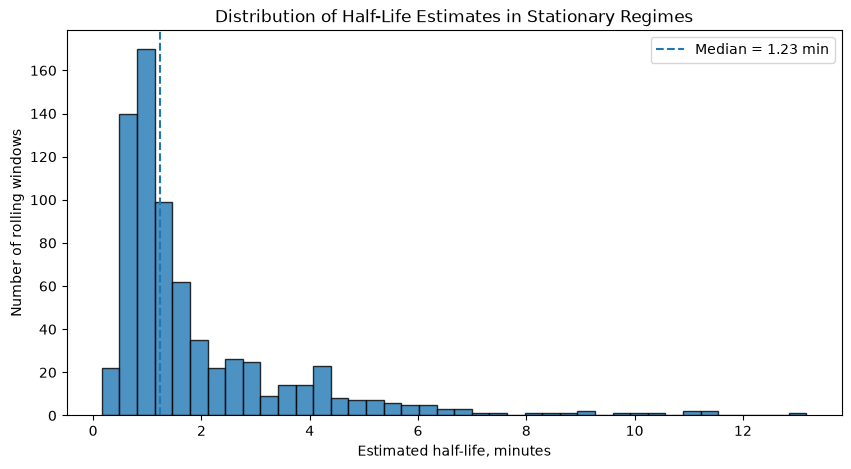

In [64]:
import matplotlib.pyplot as plt

median_hl = valid_half_lives.median()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    valid_half_lives,
    bins=40,
    edgecolor="black",
    alpha=0.8
)

ax.axvline(
    median_hl,
    linestyle="--",
    label=f"Median = {median_hl:.2f} min"
)

ax.set_title("Distribution of Half-Life Estimates in Stationary Regimes")
ax.set_xlabel("Estimated half-life, minutes")
ax.set_ylabel("Number of rolling windows")
ax.legend()

plt.show()

The relatively low joint stationarity pass rate is consistent with our findings in the EDA. The more important result for this analysis is that, conditional on the qualifying regime of joint stationarity, the estimated half-lives are generally very short, with almost 95% of them being under 5 minutes, and the mean being just under two minutes. 


This is encouraging for an intraday strategy: when the spread does enter a regime
that satisfies the stationarity filter, its estimated rate of convergence is almost always
fast enough to support our inclination towards short holding periods.

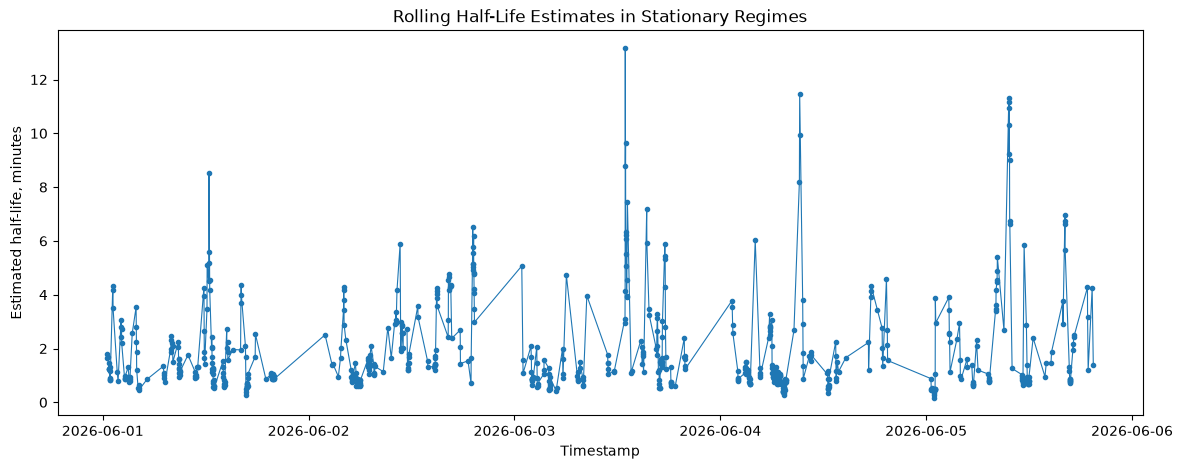

In [67]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    valid_half_lives.index,
    valid_half_lives,
    marker=".",
    linewidth=0.8
)

ax.set_title("Rolling Half-Life Estimates in Stationary Regimes")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Estimated half-life, minutes")

plt.show()

Short estimated half-lives appear throughout the sample rather than being confined
to a single period. The estimates do vary over time, reinforcing the idea that
mean-reversion speed is regime-dependent and should be re-estimated dynamically
rather than treated as a fixed property of the spread. Because consecutive estimates are calculated from heavily overlapping 30-minute
windows, neighboring observations are not independent.

In [68]:
thresholds = [1, 2, 3, 5, 10]

threshold_results = pd.DataFrame({
    "max_half_life": thresholds,
    "windows_retained": [
        (valid_half_lives <= threshold).sum()
        for threshold in thresholds
    ],
    "retention_rate": [
        (valid_half_lives <= threshold).mean()
        for threshold in thresholds
    ],
})

threshold_results

,max_half_life,windows_retained,retention_rate
0,1,282,0.391667
1,2,510,0.708333
2,3,596,0.827778
3,5,675,0.937500
4,10,714,0.991667


One of the entry filters that would play an important role in the execution of the strategy is quick mean reversion- from all of our analyses thus far, we are inclined toward making this a heavily intraday strategy that uses short time windows and holding periods, because as more time passes, mean reversion slows and the spread's size becomes increasingly vulnerable to regime shifts. Using the results seen in this notebook, we can decide on the best mean reversion threshold to use as an entry filter for our strategy.

Given that the retention rate of time steps stays very high up to even 5 minute half-lives, the best consideration moving forward would be to use 2-minute, 3-minute, and 5-minute filters during our backtest to see what filter proves to be the most effective from a P&L standpoint. 

## Conclusion

The Brent–WTI spread does not exhibit persistent mean reversion throughout the sample:
only a minority of rolling 30-minute windows satisfy both the ADF and KPSS stationarity
criteria. This supports treating mean reversion as a temporary market regime rather than
a permanent property of the spread.

Conditional on these locally stationary regimes, however, estimated half-lives are
generally short and concentrated at horizons of only a few minutes. This suggests that
when mean reversion is present, it is typically fast enough to support an intraday trading
strategy.

This analysis coupled with our EDA and stationarity analysis have produced some notable implications for what should be tested in the backtesting phase of implementation. First, it should compare alternative stationarity rules, including the current ADF + KPSS requirement, in addition to less restrictive filters (e.g. only ADF passes, one of the two tests pass, etc.). The half-life appears useful as another mean reversion diagnostic as well as a regime-quality filter: after a candidate
signal is generated and local mean reversion is identified according to some test, the strategy can reject regimes
whose estimated convergence is too slow. At times, one test passing along with a comfortable half-life that is below our threshold may be more economically meaningful than both tests passing. Thus, it is crucial to test the realized P&L results across mulitple filter configurations to see which are the most profitable. 